In [23]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [24]:
os.getuid()

1000

In [39]:
DECAY_RATE = 1

start_datetime_str = "2024-11-04 15-18-27"
end_datetime_str = "2024-11-05 08-00-00"

# end_datetime_str = start_datetime_str = "2024-11-04 14-38-04"
# end_datetime_str = start_datetime_str = "2024-10-31 13-46-21"
# end_datetime_str = start_datetime_str = "2024-11-06 11-00-44" # Error of unchanged observation
# end_datetime_str = start_datetime_str = "2024-11-06 12-08-58"

# contain large buffer and reset buffer [true, false]
start_datetime_str = "2024-11-06 12-08-58"
end_datetime_str = "2024-11-06 13-27-35"

# contain large buffer and reset buffer [true, false] with bugfix on robot pursuit
start_datetime_str = "2024-11-07 08-38-32"
end_datetime_str = "2024-11-07 10-41-32"

# end_datetime_str = start_datetime_str = "2024-11-07 11-31-51"
end_datetime_str = start_datetime_str = "2024-11-09 14-13-27"

# Full run at server
start_datetime_str = "2024-11-07 14-35-44"
end_datetime_str = "2024-11-08 04-58-17"

# Test
end_datetime_str = start_datetime_str = "2024-11-08 21-30-23"
end_datetime_str = start_datetime_str = "2024-11-09 20-42-20"


# Full SAC run at server
# start_datetime_str = "2024-11-08 22-32-12"
# end_datetime_str = "2024-11-09 06-05-21"

df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False
                                )

df.head()

Load path: /home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2024-11-09/20-42-20


,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 293,Image pixel 294,Image pixel 295,Image pixel 296,Image pixel 297,Image pixel 298,Image pixel 299,absolute_path,exp_config,experiment_path
0,0.000,0.489796,None,0.489796,1,1,circle_red,0,train,True,...,0.0,0.466667,0.0,0.0,0.466667,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
1,0.000,0.122449,None,0.612245,1,1,circle_red,1,train,True,...,0.0,0.466667,0.0,0.0,0.466667,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
2,0.165,0.040816,None,0.653061,1,1,circle_red,2,train,True,...,0.0,0.466667,0.0,0.0,0.462745,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
3,0.330,0.081633,None,0.734694,1,1,circle_red,3,train,True,...,0.0,0.462745,0.0,0.0,0.458824,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...
4,0.495,0.000000,None,0.734694,1,1,circle_red,4,train,True,...,0.0,0.462745,0.0,0.0,0.462745,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...


In [40]:
exp_config = df.exp_config.values[0]
df = df.reindex()
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    buffer_size = row.exp_config["scenario"]["buffer_size"]
    learning_starts = row.exp_config["scenario"]["learning_starts"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    return category, controller, is_reset_buffer, buffer_size, learning_starts
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

tmp = df.apply(extract_columns, axis=1, result_type='expand')
# tmp = df.exp_config.apply(extract_columns)
tmp.columns = ["category", "controller", "is_reset_buffer", "buffer_size", "learning_starts"]
df = pd.concat([df, tmp], axis=1)

In [41]:
df.head()

,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 298,Image pixel 299,absolute_path,exp_config,experiment_path,category,controller,is_reset_buffer,buffer_size,learning_starts
0,0.000,0.489796,None,0.489796,1,1,circle_red,0,train,True,...,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,LineFollowing,SAC,False,16000,400
1,0.000,0.122449,None,0.612245,1,1,circle_red,1,train,True,...,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,LineFollowing,SAC,False,16000,400
2,0.165,0.040816,None,0.653061,1,1,circle_red,2,train,True,...,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,LineFollowing,SAC,False,16000,400
3,0.330,0.081633,None,0.734694,1,1,circle_red,3,train,True,...,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,LineFollowing,SAC,False,16000,400
4,0.495,0.000000,None,0.734694,1,1,circle_red,4,train,True,...,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,LineFollowing,SAC,False,16000,400


In [42]:
pd.Series(tmp.iloc[0], index=["category", "controller", "is_reset_buffer", "buffer_size"])

category           LineFollowing
controller                   SAC
is_reset_buffer            False
buffer_size                16000
Name: 0, dtype: object

In [43]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "buffer_size"]).last()
group_df

,,,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,task_name,step_id,phase,exploration,...,Image pixel 295,Image pixel 296,Image pixel 297,Image pixel 298,Image pixel 299,absolute_path,exp_config,experiment_path,is_reset_buffer,learning_starts
controller,category,buffer_size,,,,,,,,,,,,,,,,,,,,,
SAC,LineFollowing,16000,4.62,0.938776,None,26.693878,1,637,circle_yellow,3272,train,False,...,0.0,0.0,0.0,0.0,0.0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,400


In [44]:
group_df.index.names, group_df.index[0]

(FrozenList(['controller', 'category', 'buffer_size']),
 ('SAC', 'LineFollowing', 16000))

In [45]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'LineFollowing', 16000)],
           names=['controller', 'category', 'buffer_size'])

In [46]:
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index[0]]

In [47]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [48]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/venv/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

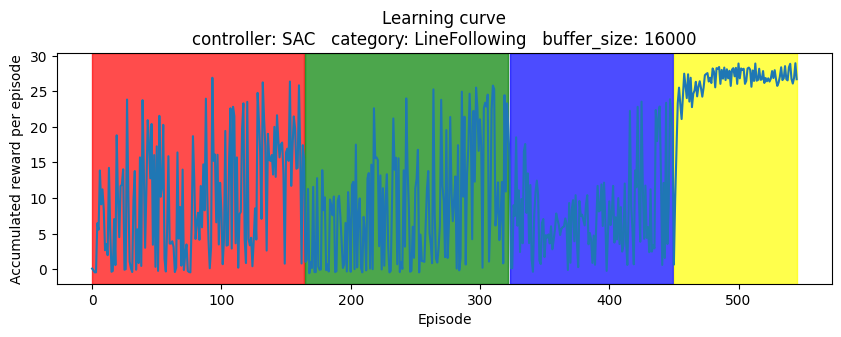

In [49]:
import matplotlib.pyplot as plt
# import matplotlib
# %matplotlib inline

def plot_learning_curve(index, index_names, df):
    fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    # Filter exploration actions
    tmp_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
    tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
    tmp_group_df = tmp_df.groupby("iteration_id")

    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "last", 
        "task_name": "last",
        "step_id": "last"
        })
    
    # Re-assign index for ploting
    tmp_group_df = tmp_group_df.reset_index()
    tmp_group_df.iteration_id = tmp_group_df.reset_index().index
    tmp_group_df = tmp_group_df.set_index("iteration_id")

    tmp_group_df.plot(y="current_undiscounted_value", ax=ax)

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.7, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Accumulated reward per episode')
    ax.set_title(
        'Learning curve\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()


for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df)
# plot_learning_curve(group_df.index[1], group_df.index.names, df)
# plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)
# plot_learning_curve(('TD3', 'LineFollowing', False), group_df.index.names, df)
# plt.show()

,step_id,task_name,current_undiscounted_value,learning_starts,phase
iteration_id,,,,,
0,410,circle_red,0.102041,400,train
1,421,circle_red,-0.142857,400,train
2,428,circle_red,-0.428571,400,train
3,433,circle_red,-0.428571,400,train
4,449,circle_red,6.469388,400,train
...,...,...,...,...,...
541,3152,circle_yellow,26.734694,400,train
542,3182,circle_yellow,26.081633,400,train
543,3212,circle_yellow,26.897959,400,train


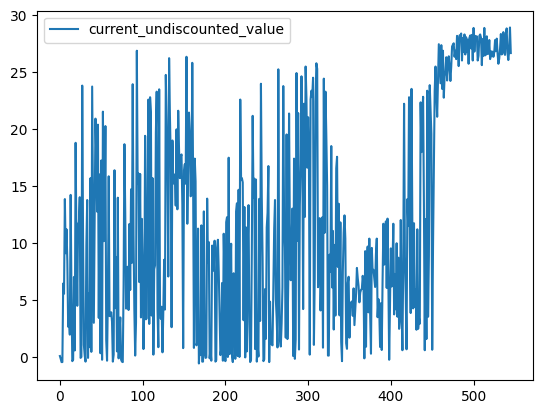

In [50]:
tmp_df = df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
g = tmp_df.groupby("iteration_id").last()
g = g.reset_index()
g.iteration_id = g.reset_index().index
g.plot(y="current_undiscounted_value")
g.set_index("iteration_id")

In [51]:
df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
df[df.running_objective == 10].loc[['SAC']]

KeyError: "['SAC'] not in index"

<Axes: xlabel='iteration_id'>

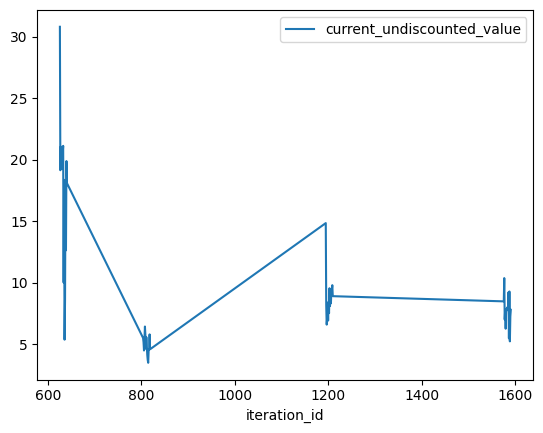

In [16]:
df = df.reset_index().set_index(["controller", "category", "buffer_size", "task_name"])
df = df.reset_index().set_index(group_df.index.names)
tmp_df = df.loc[group_df.index]

tmp_group_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "phase"]].groupby("iteration_id")
tmp_group_df = tmp_group_df.aggregate({
    "current_undiscounted_value": "mean", 
    "task_name": "last",
    "step_id": "last",
    "phase": "last"
    })
tmp_group_df[tmp_group_df.phase=="eval"].plot(y="current_undiscounted_value")

/tmp/ipykernel_128802/368340058.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_128802/368340058.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_128802/368340058.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_128802/368340058.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_128802/368340058.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]
/tmp/ipykernel_128802/368340058.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]


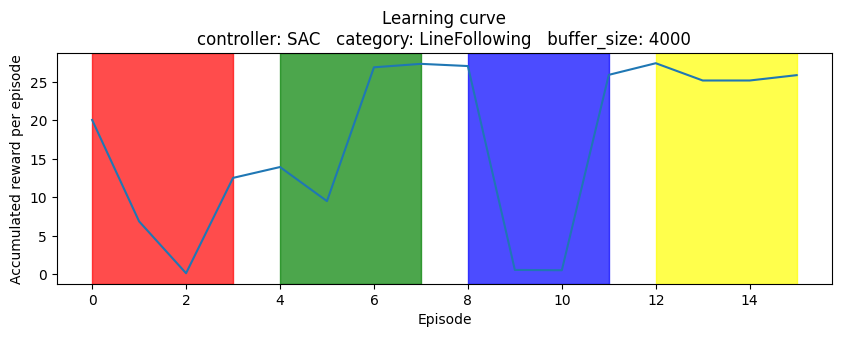

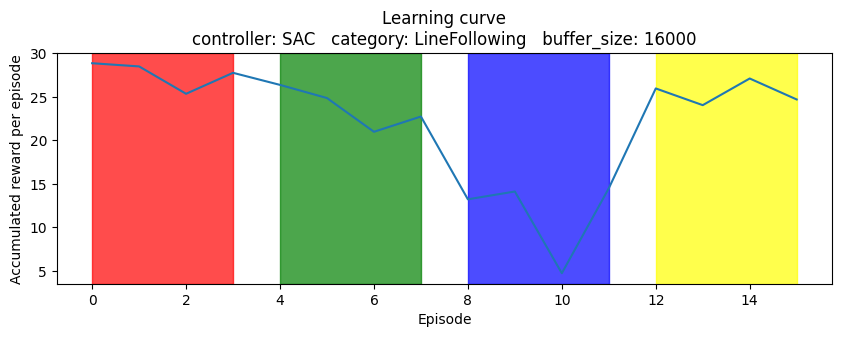

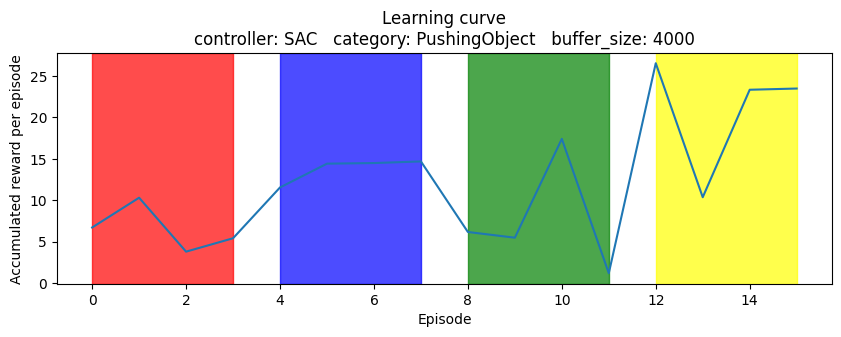

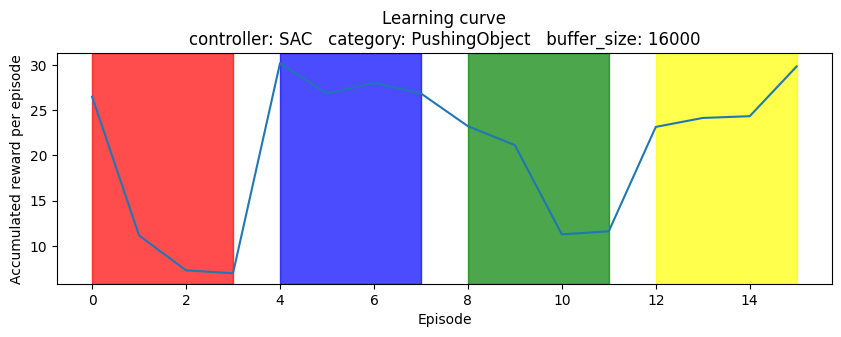

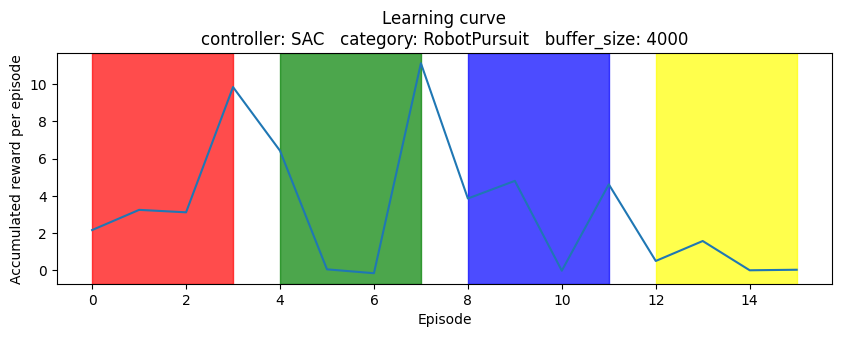

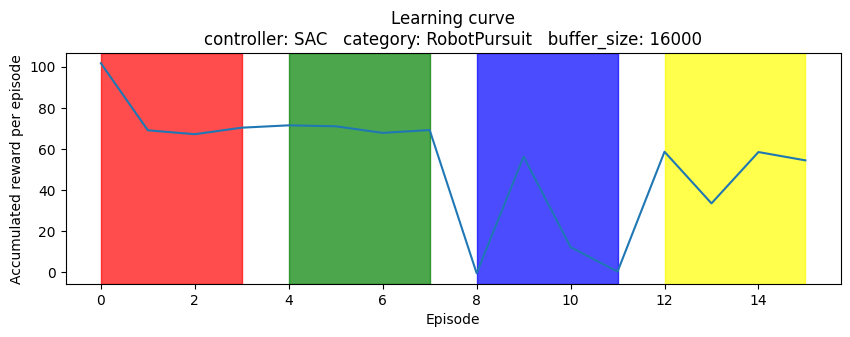

In [17]:
for id in group_df.index:
    plot_learning_curve(id, group_df.index.names, df[df.phase=="eval"])

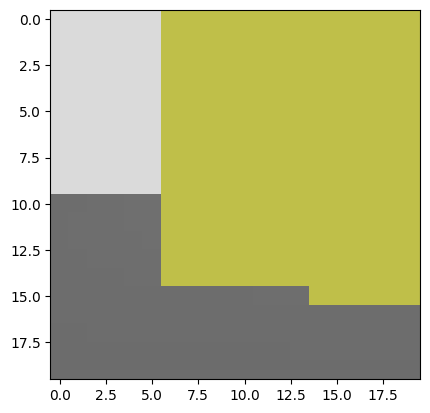

In [18]:
# df = df.reset_index()
pixel_columns = [c for c in df.columns if "pixel" in c.lower()]
chosen_state = np.array(df.loc[:, pixel_columns].iloc[-1])
im = chosen_state.reshape((20, 20, 3))

plt.imshow(im)

In [19]:
# from src.objective import RobotPursuitRunningObjective

# objective_func = RobotPursuitRunningObjective()

# objective_func(state=im, 
#                catcher_pos=[1, 1], 
#                runner_pos=[0, 0], 
#                action=[1, 0], 
#                step_count=0, 
#                max_steps_per_episode=100,
#                runner_collision_thickness=0.49,
#                arena_bounds=[-2.5,2.5,-2.5,2.5],
#                info={})

In [20]:
import numpy as np
np.sum(im)

698.2235

/tmp/ipykernel_128802/368340058.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  tmp_df = df.loc[index]


KeyError: False

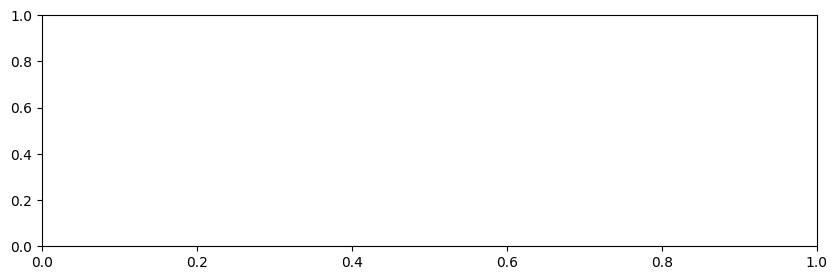

In [21]:
plot_learning_curve(('SAC', 'LineFollowing', False), group_df.index.names, df)
plot_learning_curve(('SAC', 'LineFollowing', True), group_df.index.names, df)

In [ ]:
tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]
tmp_df[(tmp_df.step_id.diff() < 0)]
# tmp_df.step_id.values.tolist()[1:]+ [tmp_df.step_id.values.tolist()[-1]]

/tmp/ipykernel_127043/3476527340.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp_df["previous_step"] = [tmp_df.step_id.values.tolist()[0]] + tmp_df.step_id.values.tolist()[:-1]


index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                6  0.000           0.408163   
                         False                8  0.198           0.000000   
                         False                9  0.363           0.000000   
                         False               10  0.528           0.000000   
                         False               11  0.693           0.000000   
                         False                2  0.000           0.693878   
                         False               15  0.000           0.734694   
                         False               18  0.363           0.979592   
                         False               19  0.528           0.979592   
                         False               20  0.693           0.897959   
                         False               21  0.858           0.775510   
                         False               22  1.023           0.530612   
                         False               23  1.188           0.285714   
                         False               24  1.353           0.081633   
                         False               25  1.518           0.040816   
                         False               26  1.683          -1.000000   
                         False                0  0.000           0.530612   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer                               
SAC        LineFollowing False                              2.693878   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.857143   
                         False                              2.122449   
                         False                              5.755102   
                         False                              8.448980   
                         False                              9.428571   
                         False                             10.326531   
                         False                             11.102041   
                         False                             11.632653   
                         False                             11.918367   
                         False                             12.000000   
                         False                             12.040816   
                         False                             11.040816   
                         False                              0.530612   

                                          episode_id  iteration_id  \
controller category      is_reset_bu

In [ ]:
tmp_df[tmp_df.iteration_id == 1196]

index   time  running_objective  \
controller category      is_reset_buffer                                    
SAC        LineFollowing False                0  0.000           0.693878   
                         False                1  0.000           0.857143   
                         False               15  0.000           0.734694   
                         False               16  0.000           0.775510   
                         False               17  0.165           0.938776   
                         False                2  0.198           0.979592   
                         False                3  0.363           0.775510   
                         False               18  0.363           0.979592   
                         False                4  0.528           0.408163   
                         False               19  0.528           0.979592   
                         False                5  0.693           0.448980   
                         False               20  0.693           0.897959   
                         False                6  0.858           0.326531   
                         False               21  0.858           0.775510   
                         False                7  1.023           0.122449   
                         False               22  1.023           0.530612   
                         False                8  1.188           0.040816   
                         False               23  1.188           0.285714   
                         False                9  1.353           0.040816   
                         False               24  1.353           0.081633   
                         False               10  1.518           0.040816   
                         False               25  1.518           0.040816   
                         False               11  1.683           0.000000   
                         False               26  1.683          -1.000000   
                         False               12  1.848           0.081633   
                         False               13  2.013           0.081633   
                         False               14  2.178           0.122449   

                                         current_value  \
controller category      is_reset_buffer                 
SAC        LineFollowing False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   
                         False                    None   

                                          current_undiscounted_value  \
controller category      is_reset_buffer             